---
title: Heart disease prediction
image: ./images/hds.png
jupyter: python3
ord: 1
description: Data analysis, Random Forest and Logistic Regression with heart disease dataset
format:
    html:
        code-fold: true
        toc: true
        
---
      

In [1]:
#| code-summary: "Imports"

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import palettable
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score

# Data

The data is available at UCI [machine learning repository](https://archive.ics.uci.edu/ml/datasets/heart+disease).

The website contains 4 datasets concerning heart disease diagnosis.The data for these datasets was collected from the four following locations:

    1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
    2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
    3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
    4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

There are 2 versions of each dataset:

* Full dataset with 76 attributes
* Dataset with 14 attributes

The reduced dataset exists because only the subset of 14 attributes has been used in prior reseach and experiments.

Files used for this project:

- `processed.switzerland.data`
- `processed.cleveland.data`
- `processed.hungarian.data`
- `processed.va.data`

I create a single dataset by combining these four.

In [4]:
#| code-summary: "Download data"
#| output: false
!wget https://archive.ics.uci.edu/static/public/45/heart+disease.zip
!mkdir heart_disease_data
!unzip heart+disease.zip -d heart_disease_data 

--2023-10-13 20:48:54--  https://archive.ics.uci.edu/static/public/45/heart+disease.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart+disease.zip’

heart+disease.zip       [         <=>        ] 125.87K  63.2KB/s    in 2.0s    

2023-10-13 20:48:58 (63.2 KB/s) - ‘heart+disease.zip’ saved [128894]

Archive:  heart+disease.zip
  inflating: heart_disease_data/Index  
  inflating: heart_disease_data/WARNING  
  inflating: heart_disease_data/ask-detrano  
  inflating: heart_disease_data/bak  
  inflating: heart_disease_data/cleve.mod  
  inflating: heart_disease_data/cleveland.data  
   creating: heart_disease_data/costs/
  inflating: heart_disease_data/costs/Index  
  inflating: heart_disease_data/costs/heart-disease.README  
  inflating: heart_disease_data/costs/heart-disease.cost  
  inflatin

### Creating a single dataset

The datasets have the same columns, they don't have headers, and missing values are provided as `?`.

In [2]:
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak",
          "slope", "ca", "thal", "disease"]
sdf = pd.read_csv("heart_disease_data/processed.switzerland.data", header=None, names=columns, na_values='?')
cdf = pd.read_csv("heart_disease_data/processed.cleveland.data", header=None, names=columns, na_values='?')
hdf = pd.read_csv("heart_disease_data/processed.hungarian.data", header=None, names=columns, na_values='?')
vdf = pd.read_csv("heart_disease_data/processed.va.data", header=None, names=columns, na_values='?')

df = pd.concat([sdf, cdf, vdf, hdf], ignore_index=True)
df.disease = df['disease'].apply(lambda x: 1 if x > 0 else 0)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,disease
0,32.0,1.0,1.0,95.0,0.0,NaN,0.0,127.0,0.0,0.7,1.0,NaN,NaN,1
1,34.0,1.0,4.0,115.0,0.0,NaN,NaN,154.0,0.0,0.2,1.0,NaN,NaN,1
2,35.0,1.0,4.0,NaN,0.0,NaN,0.0,130.0,1.0,NaN,NaN,NaN,7.0,1
3,36.0,1.0,4.0,110.0,0.0,NaN,0.0,125.0,1.0,1.0,2.0,NaN,6.0,1
4,38.0,0.0,4.0,105.0,0.0,NaN,0.0,166.0,0.0,2.8,1.0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,52.0,1.0,4.0,160.0,331.0,0.0,0.0,94.0,1.0,2.5,NaN,NaN,NaN,1
916,54.0,0.0,3.0,130.0,294.0,0.0,1.0,100.0,1.0,0.0,2.0,NaN,NaN,1
917,56.0,1.0,4.0,155.0,342.0,1.0,0.0,150.0,1.0,3.0,2.0,NaN,NaN,1
918,58.0,0.0,2.0,180.0,393.0,0.0,0.0,110.0,1.0,1.0,2.0,NaN,7.0,1


### Attributes

#### Numerical attributes

- `age`: age in years, numerical

- `trestbps` - resting blood pressure (in mm Hg on admission to the hospital)
- `chol` - cholesterol in mg/dl
- `thalach` - maximum heart rate achieved
- `oldpeak` - ST depression induced by exercise relative to rest. ‘ST’ relates to the positions on the electrocardiographic (ECG) plot.
- `ca` - number of major vessels (0-3) colored by flourosopy. Fluoroscopy is one of the most popular non-invasive coronary artery disease diagnosis. It enables the doctor to see the flow of blood through the coronary arteries in order to evaluate the presence of arterial blockages.

#### Categorical attributes
- `sex`: sex
    - 1 = male
    - 0 = female
- `cp`: chest pain type
    - 1: typical angina
    - 2: atypical angina
    - 3: non-anginal pain
    - 4: asymptomatic
- `fbs` - fasting blood sugar > 120 mg/dl
    - 1 = true
    - 0 = false
- `restecg` - resting electrocardiographic (ECG) results
    - 0: normal
    - 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    - 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
- `exang` - exercise induced angina. Angina is a type of chest pain caused by reduced blood flow to the heart.
    - 1 - yes
    - 0 - no
- `slope` - the slope of the peak exercise ST segment. (ECG)
    - 1: upsloping
    - 2: flat
    - 3: downsloping
- `thal` - A blood disorder called thalassemia
     - 3: normal blood flow
     - 6: fixed defect (no blood flow in some part of the heart)
     - 7: reversable defect (a blood flow is observed but it is not normal)
- `disease` - refers to the presence of heart disease in the patient. It is integer valued from 0 (no presence) to 4.

## Exploratory data analysis





In [44]:
#| code-summary: "EDA helper functinos"

df_eda = df.copy()

def plot_categorical(data=pd.DataFrame,
                     column=str,
                     labels=[],
                     target='disease',
                     target_labels=['healthy', 'heart disease'],
                     title='', font = 10, ax = None):
    crosstab = pd.crosstab(data[column], data[target])
    ax = crosstab.plot(kind='bar', figsize=(15, 7), rot = 0, fontsize=font, ax=ax)
    x = np.arange(len(labels))
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(target_labels)
    plt.ylabel("count", size=14)
    plt.title(title)

    bars =  ax.patches

    #compute percents
    total_by_category = crosstab.sum(axis=1)
    healthy_perc = round((crosstab[0] / total_by_category ) * 100)


    for (i, bar) in enumerate(bars):
      prc = healthy_perc.iloc[i] if i < len(healthy_perc) else 100 - healthy_perc.iloc[i % len(healthy_perc)]
      plt.annotate(str(int(prc)) + '%',
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')


def plot_numeric(data=pd.DataFrame, column=str, title=str):
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(20, 7)

    #with respect to the target
    healthy = data.loc[data.disease == 0, column]
    sick = data.loc[data.disease == 1, column]
    healthy.plot.density(ax=ax[0])
    sick.plot.density(ax=ax[0])
    ax[0].legend(['healthy', 'heart disease'])

    data.boxplot(by='disease', column= [column], ax=ax[1])

    fig.suptitle(title, fontsize = 19)


def describe_numeric(data=pd.DataFrame, column=str):
    temp = data[[column, 'disease']].copy()
    temp['healthy'] = data[data.disease == 0][column]
    temp['sick'] = data[data.disease == 1][column]
    return temp[[column, 'healthy', 'sick']].describe()

def plot_missing(data = pd.DataFrame):
  na_values_percent = data.isna().sum().sort_values(ascending=False) \
    .apply(lambda x: (x, round(x / data.index.size * 100, 2))) # (count, %)
  na_values_percent.apply(lambda x: x[1]).plot.bar() # (plot %)
  plt.ylabel("Percentage", size=14)
  plt.title('Missing values')

### Numeric data summary

In [5]:
df_numeric=df_eda.loc[:,['age','trestbps','chol','thalach','oldpeak']]
df_numeric.describe()

,age,trestbps,chol,thalach,oldpeak
count,920.000000,861.000000,890.000000,865.000000,858.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788
std,9.424685,19.066070,110.780810,25.926276,1.091226
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


<AxesSubplot: >

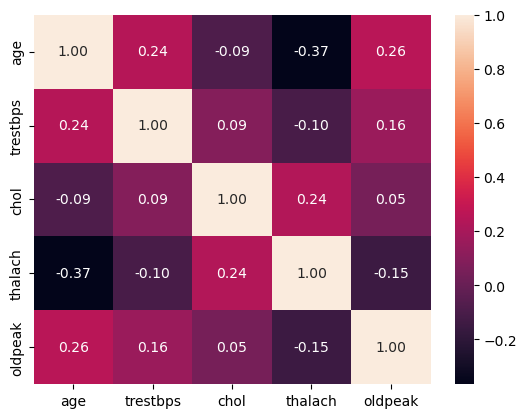

In [6]:
dcorr=df_numeric.corr(method='pearson')
sns.heatmap(data=dcorr,annot=True,fmt=".2f")

### Categorical data summary

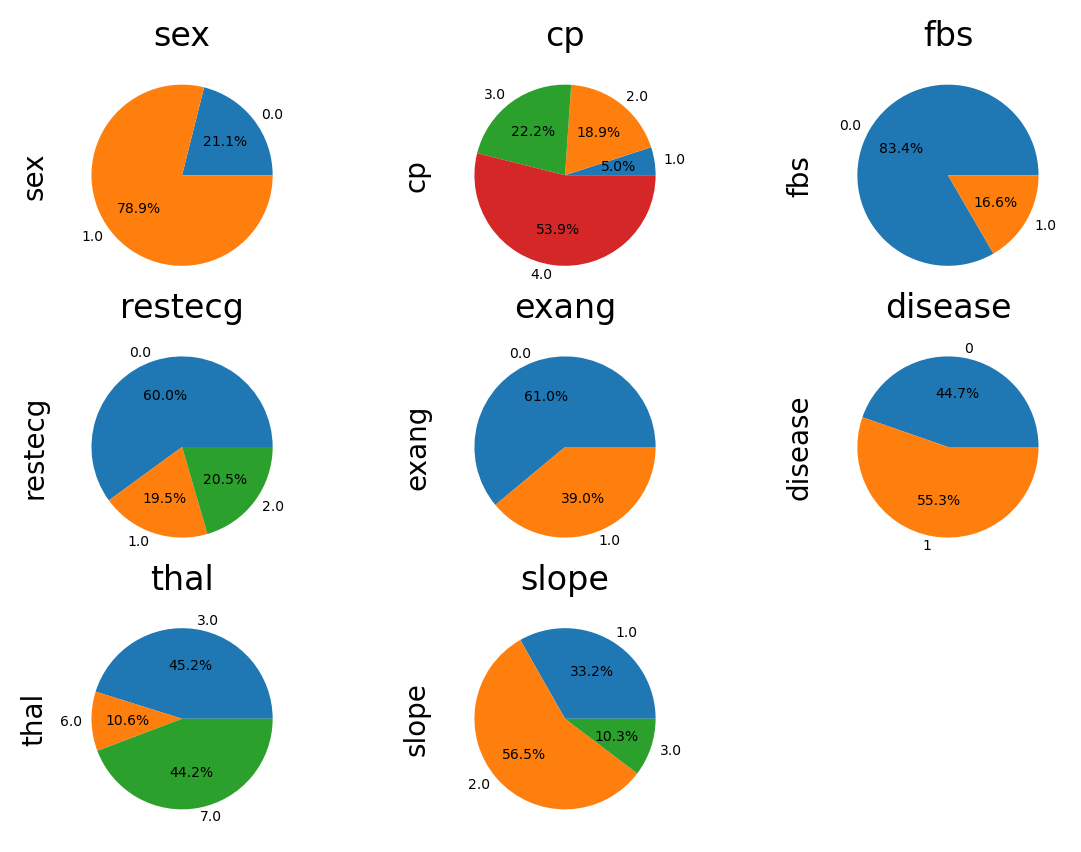

In [7]:
plt.figure(figsize=(5,5),dpi=200)
for (i, col) in enumerate(['sex','cp','fbs','restecg','exang', 'disease', 'thal', 'slope']):
  plt.subplot(3,3,i+1)
  df_eda[col].value_counts().sort_index().plot(kind='pie', figsize=(7,5), autopct='%1.1f%%', title = col, textprops={'fontsize': 5})


### Analysing risk factors for heart disease

#### Cholesterol ('chol')

Cholesterol has a lot of 0 values, which is not possible. 

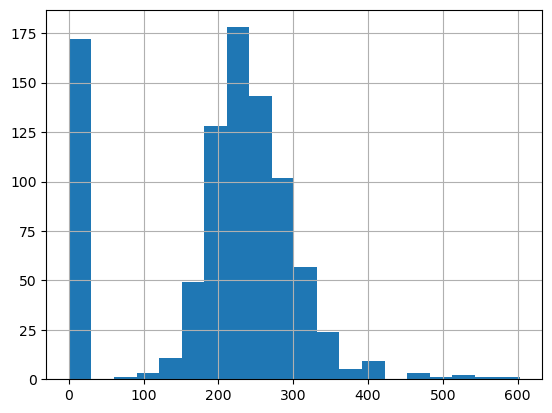

In [8]:
df_eda.chol.hist(bins=20)
df_eda['chol'] = df_eda['chol'].replace({0:np.nan})

##### Analysis

People with heart disease on average have higher colesterol level.

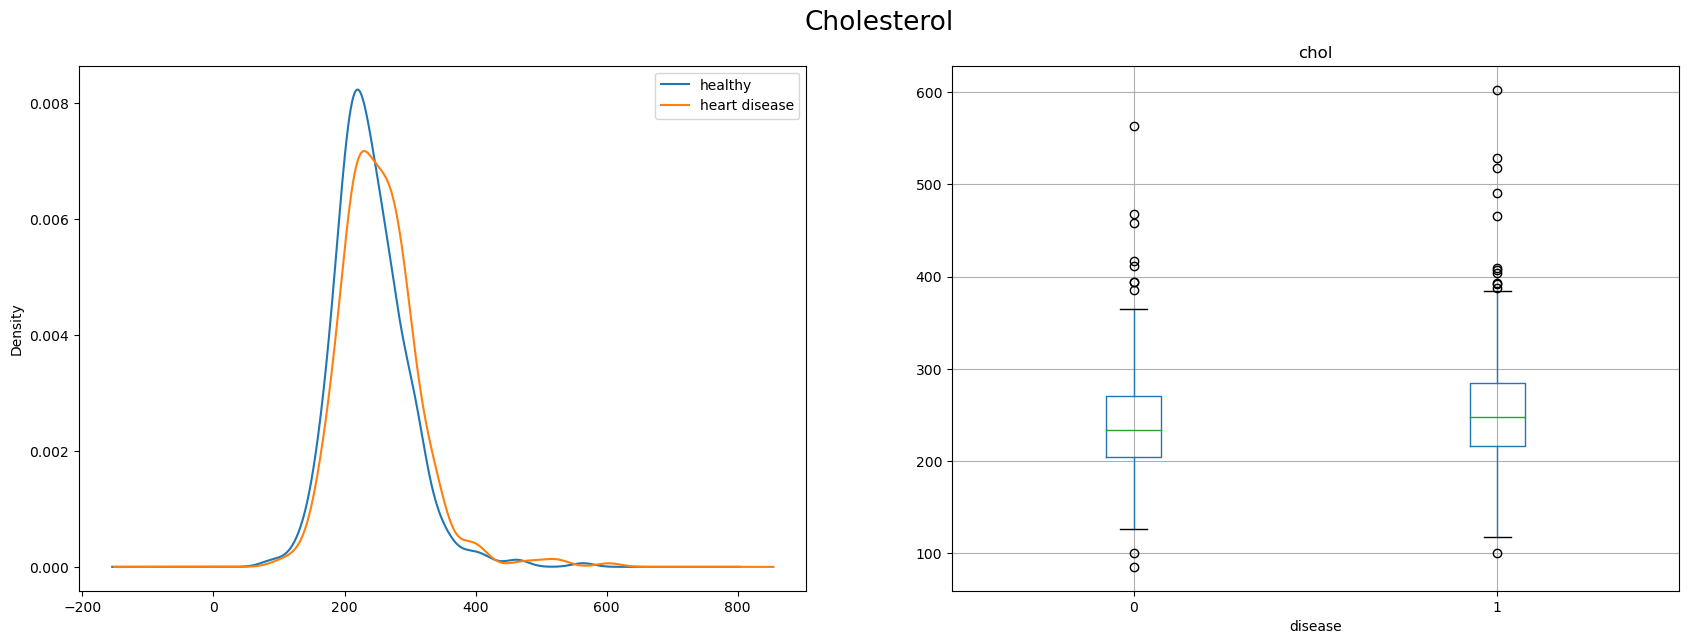

In [9]:
plot_numeric(df_eda, 'chol', 'Cholesterol')

In [10]:
describe_numeric(df_eda, 'chol')

,chol,healthy,sick
count,718.000000,372.000000,346.000000
mean,246.832869,240.158602,254.008671
std,58.527062,55.767559,60.620439
min,85.000000,85.000000,100.000000
25%,210.000000,204.000000,216.000000
50%,239.500000,233.000000,248.000000
75%,276.750000,270.250000,284.750000
max,603.000000,564.000000,603.000000


Binning shows that people with cholesterol level more than 254 mg/dl have more than 50% chance of having a heart disease.  

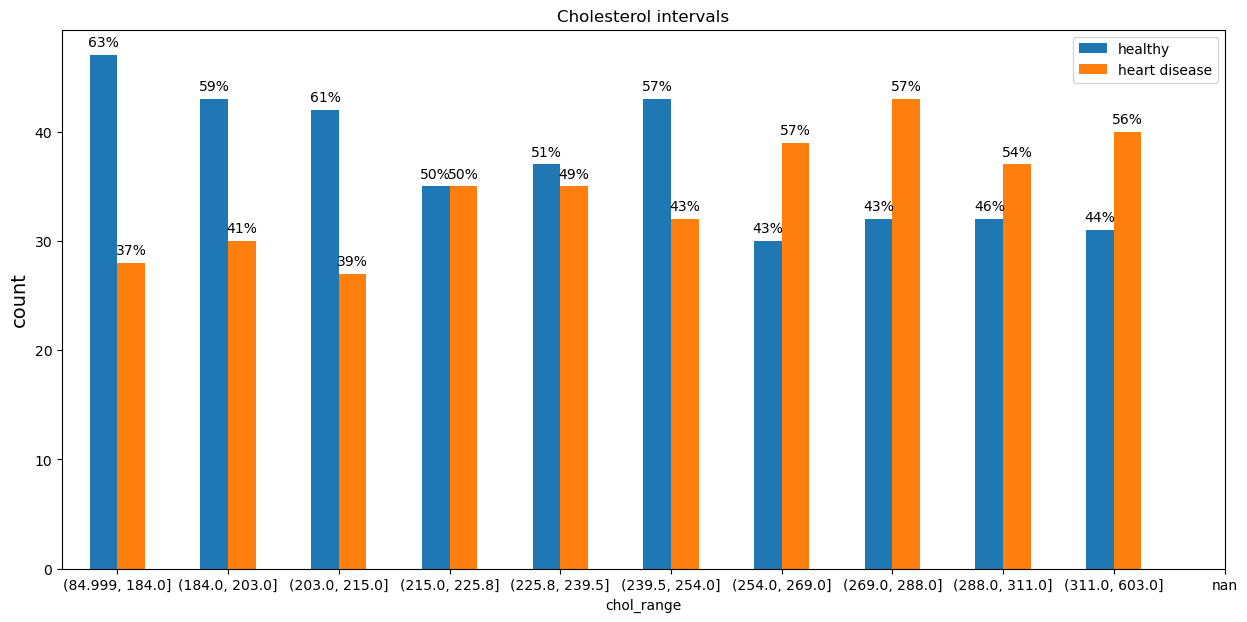

In [11]:
df_eda['chol_range'] = pd.qcut(df_eda['chol'], 10, duplicates = 'drop')
plot_categorical(df_eda, 'chol_range', df_eda.chol_range.unique().sort_values(), title = 'Cholesterol intervals')

#### Age

People with heart
disease on average are about 5 years older than healthy people.

<AxesSubplot: >

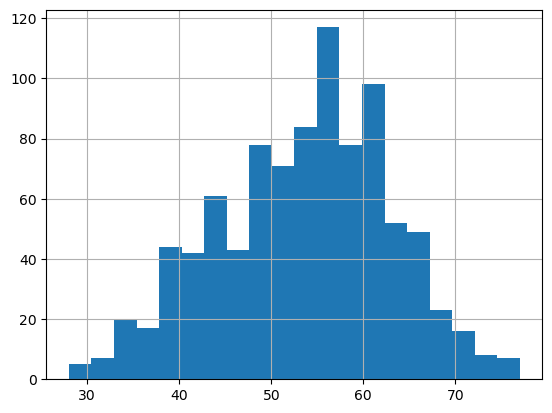

In [12]:
df_eda.age.hist(bins=20)


In [13]:
describe_numeric(df_eda, 'age')

,age,healthy,sick
count,920.000000,411.000000,509.000000
mean,53.510870,50.547445,55.903733
std,9.424685,9.433700,8.718959
min,28.000000,28.000000,31.000000
25%,47.000000,43.000000,51.000000
50%,54.000000,51.000000,57.000000
75%,60.000000,57.000000,62.000000
max,77.000000,76.000000,77.000000


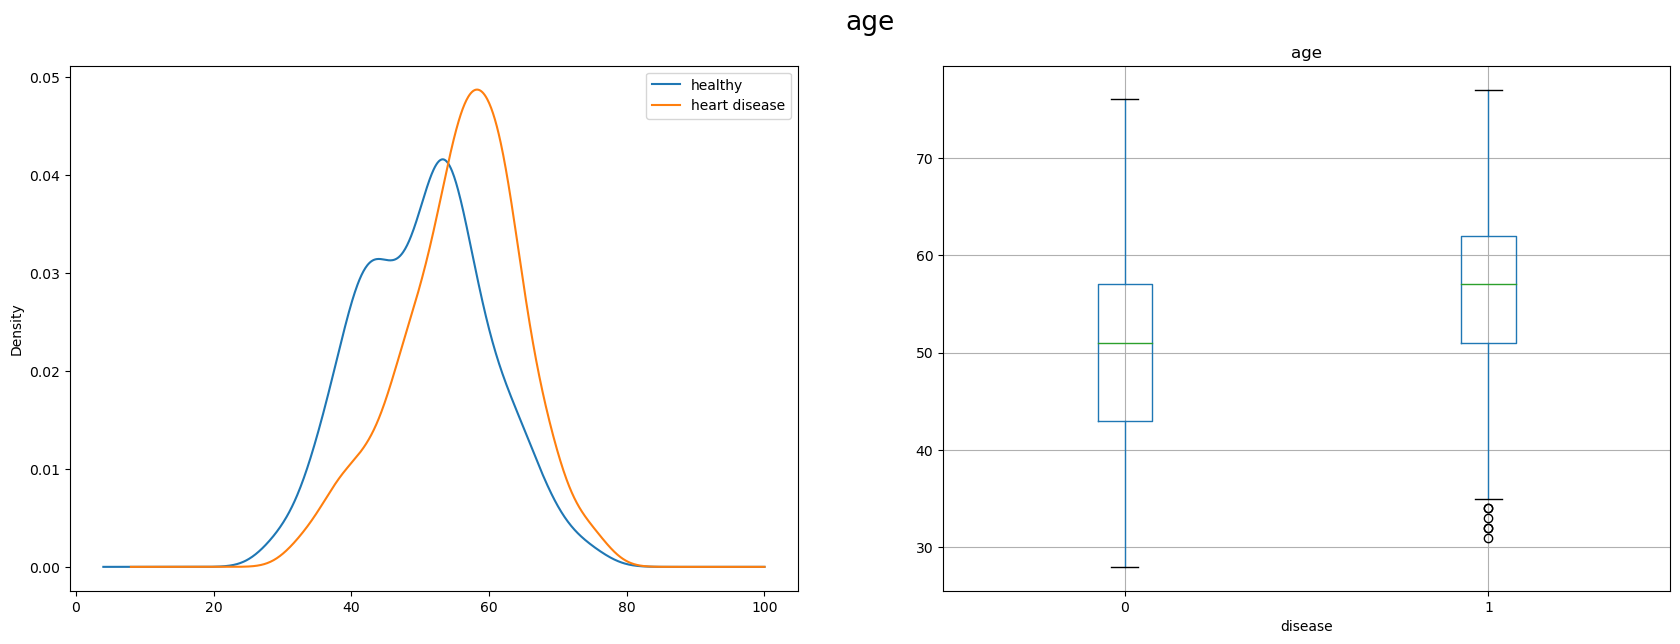

In [14]:
plot_numeric(df_eda, 'age', 'age')

We can see that the risk of getting heart disease increases after the age of 54.

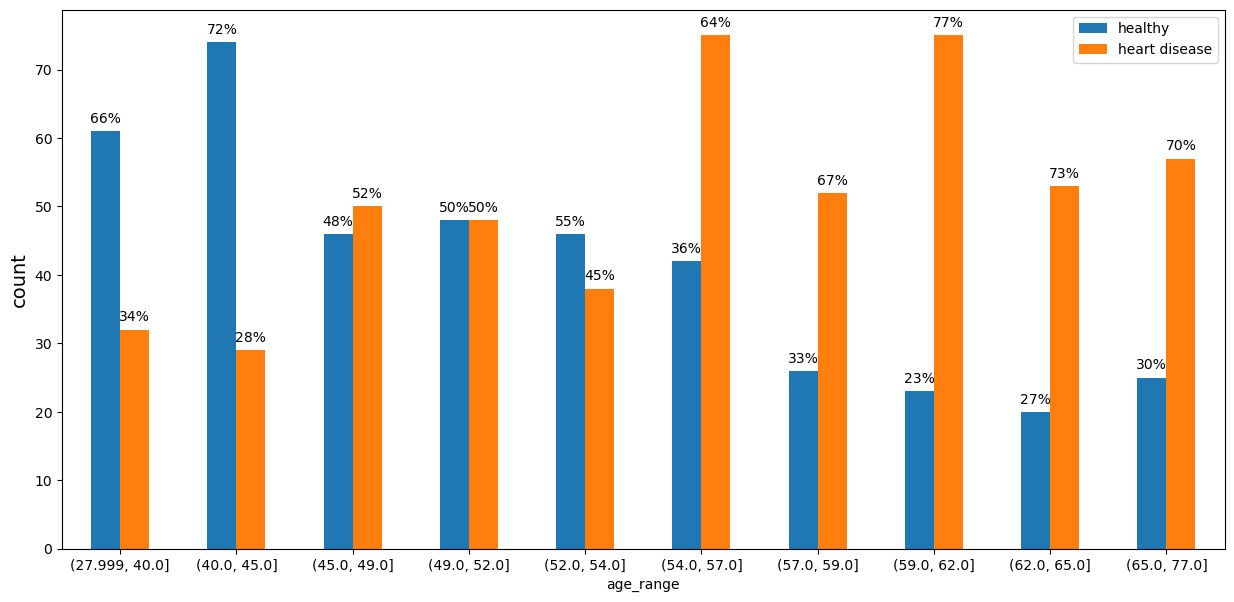

In [15]:
df_eda['age_range'] = pd.qcut(df_eda['age'], 10)
plot_categorical(df_eda, 'age_range', df_eda.age_range.unique().sort_values())

#### Resting blood pressure ('trestbps')

<AxesSubplot: >

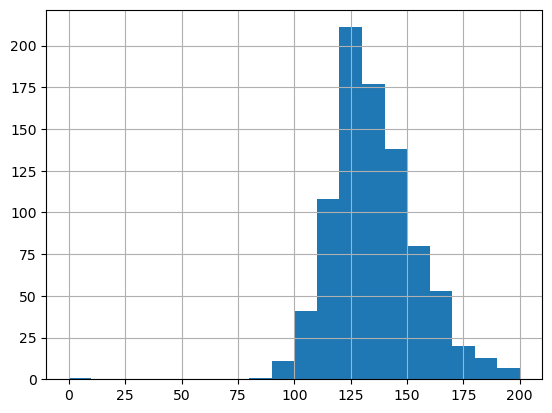

In [16]:
df_eda.trestbps.hist(bins=20)

There's one unrealistic value of 0, I replace it with na for analysis.

In [17]:
df_eda.trestbps.replace({0:np.nan}, inplace=True)

People with heart disease on average have a slightly higher blood pressure than healthy patients.

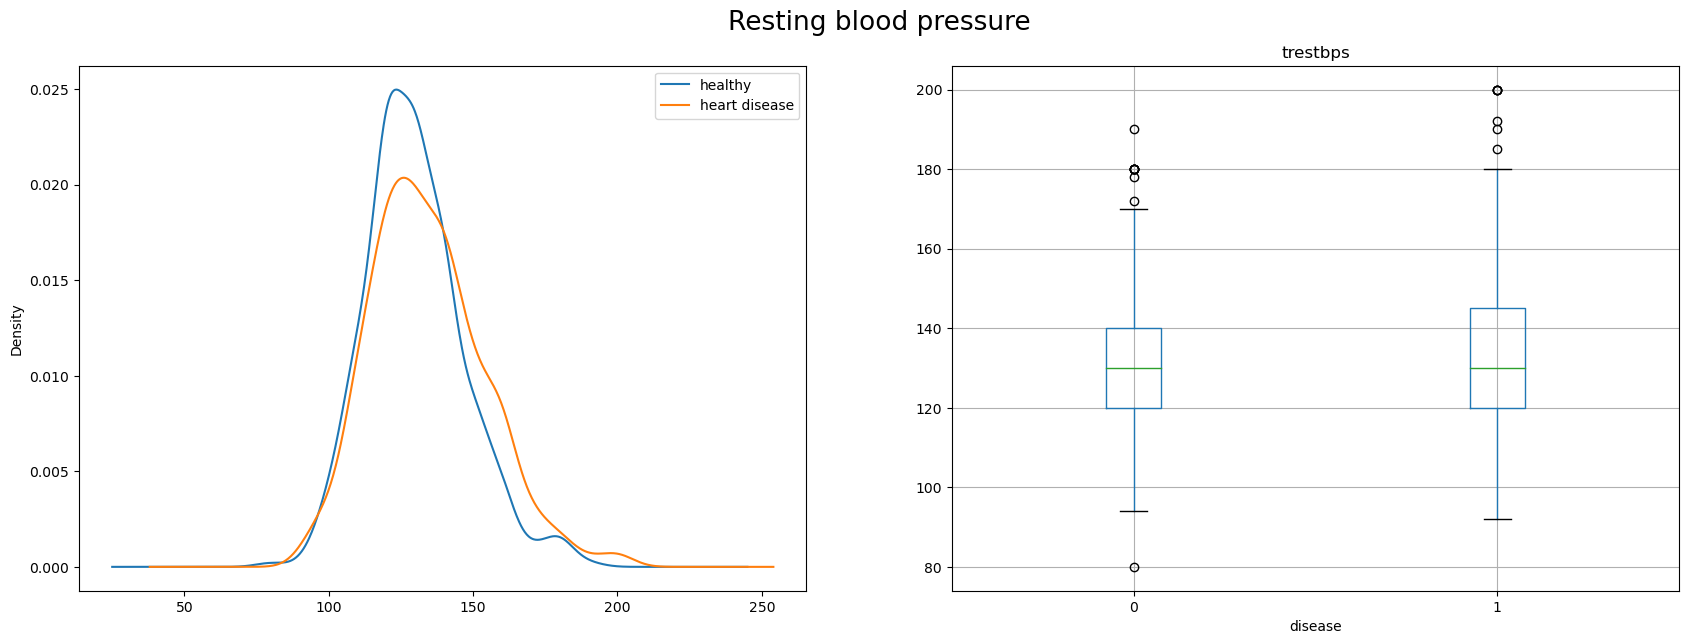

In [18]:
plot_numeric(df_eda, 'trestbps', 'Resting blood pressure')

In [19]:
describe_numeric(df_eda, 'trestbps')

,trestbps,healthy,sick
count,860.000000,391.000000,469.000000
mean,132.286047,129.913043,134.264392
std,18.536175,16.869867,19.617889
min,80.000000,80.000000,92.000000
25%,120.000000,120.000000,120.000000
50%,130.000000,130.000000,130.000000
75%,140.000000,140.000000,145.000000
max,200.000000,190.000000,200.000000


Most patients with normal blood pressure do not have heart disease, while most patients with elevated blood pressure have heart disease.

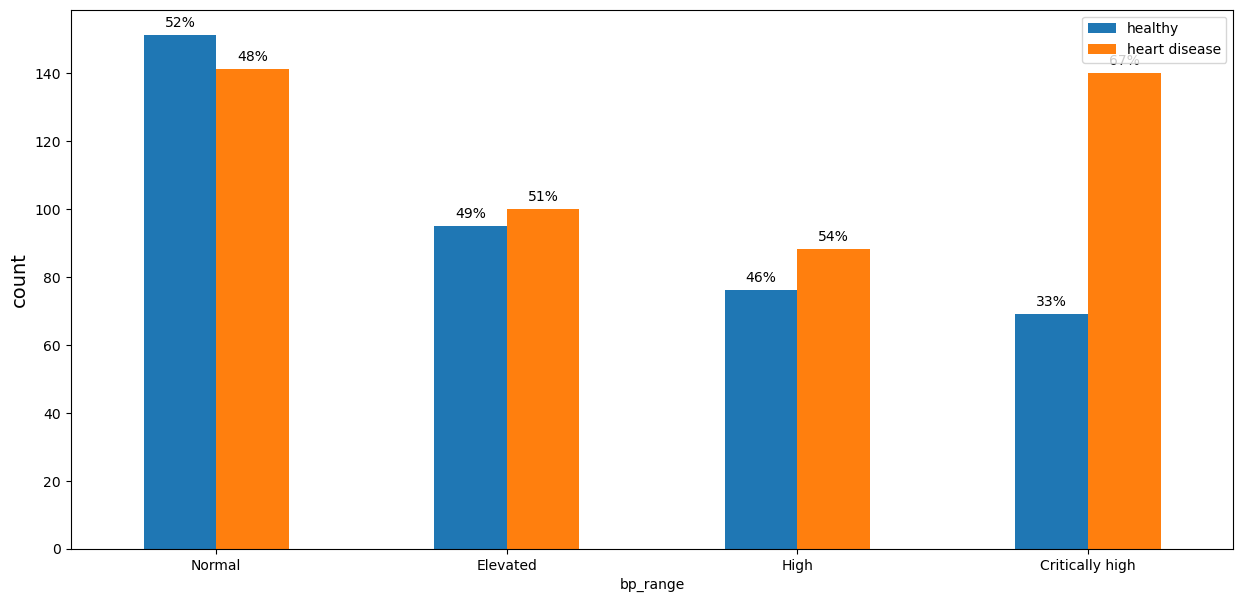

In [20]:
bins = [0, 120, 130, 140, np.inf]
labels = ['Normal', 'Elevated', 'High', 'Critically high']
df_eda['bp_range'] = pd.cut(df_eda['trestbps'], bins)
plot_categorical(df_eda, 'bp_range', labels)

#### Exercise induced angina ('exang')

Most of the patients with heart disease experienced angina during the exercise, while the majority in the healthy group had no such symptoms.

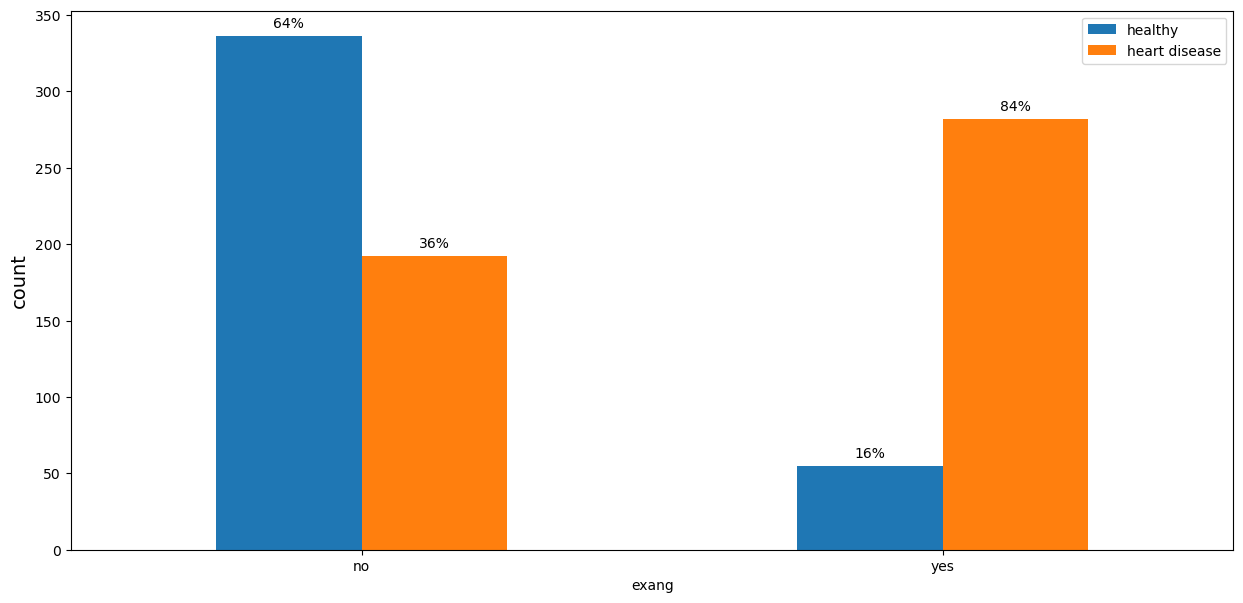

In [21]:
plot_categorical(df_eda, 'exang', ['no', 'yes'])

#### Number of Blocked Vessels ('ca')

The chance of having heart disease increases proportionally to the number of blocked vessels. Patients with 0 blocked vessels have only 27% chance of having heart disease. The value reaches 85% chance for the group with 3 blocked vessels.

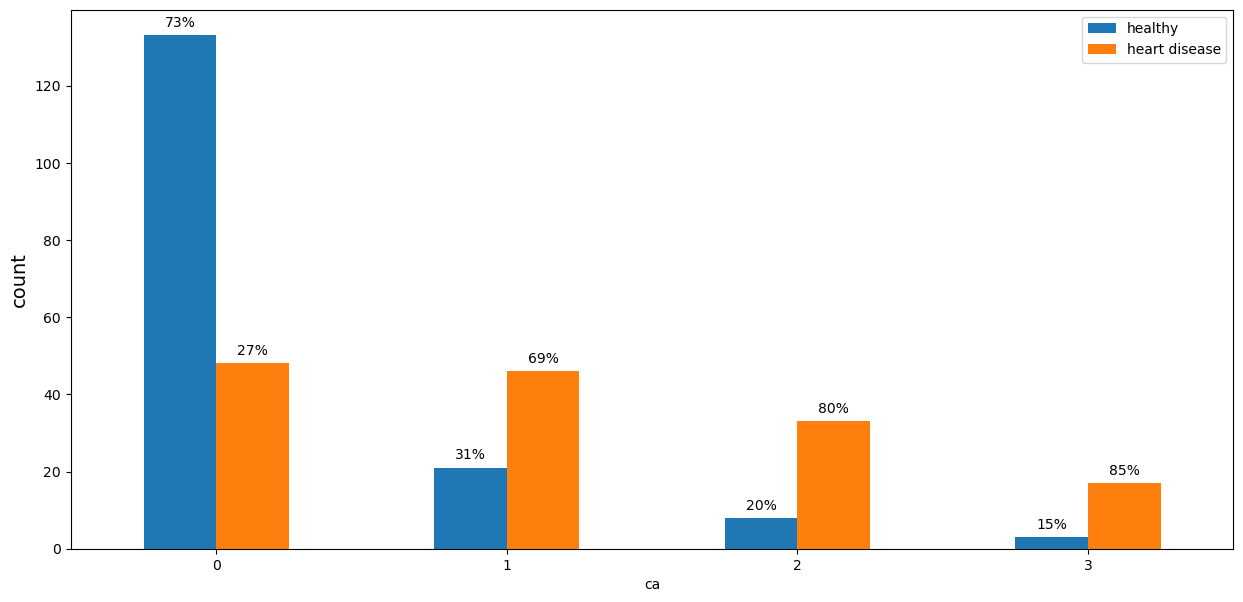

In [22]:
labels=["0", "1", "2", "3"]
plot_categorical(df_eda, 'ca', labels)

#### Gender

The majority of men in the dataset have heart disease, while only 26% of women are unhealthy.

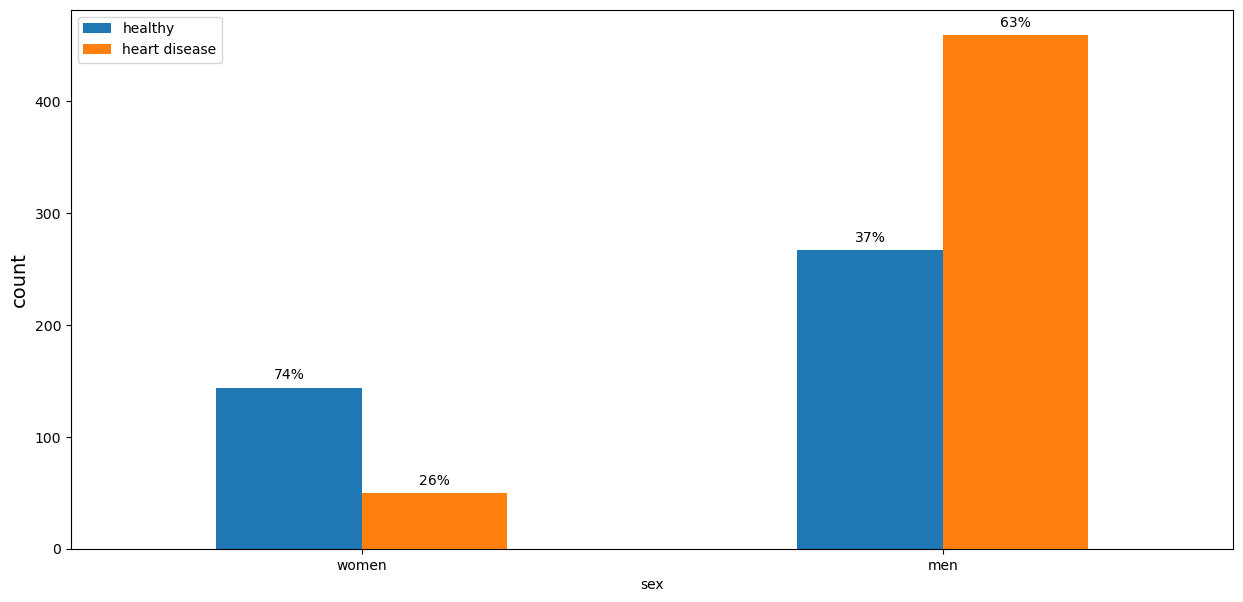

In [24]:
plot_categorical(df_eda, 'sex', ['women', 'men'])

#### Chest pain type ('cp')

Amongst the patients with no chest pain almost 80% had heart disease. Patients with the atypical angina had the lowest level of heart disease rate. Overall, we can not say if a chest pain can be considered as a risk factor for a heart disease.

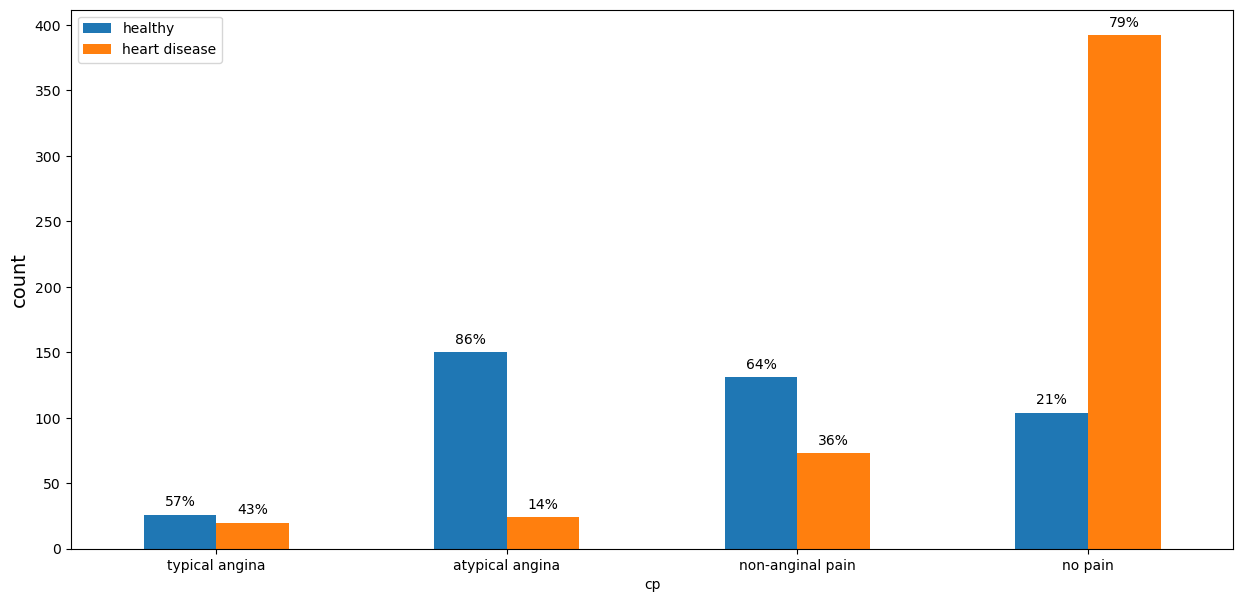

In [25]:
labels=['typical angina', 'atypical angina', 'non-anginal pain', 'no pain']
plot_categorical(df_eda, 'cp', labels)

#### Fasting blood sugar

In the dataset most people don't have a high sugar level. But among those who do, almost 70% have heart disease.

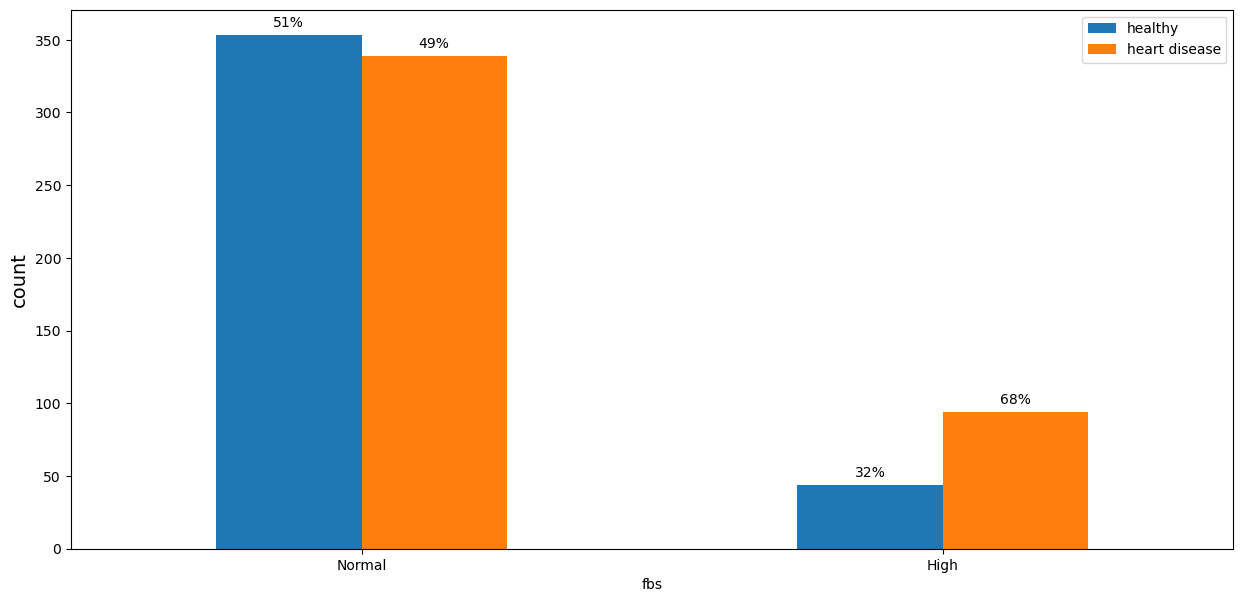

In [27]:
plot_categorical(df_eda, 'fbs', ['Normal', 'High'])

#### Resting electrocardiographic results ('restecg')

Patients in the categories with type 1 and type 2 abnormalities have higher chance of getting a heart disease than the group with normal ECG.

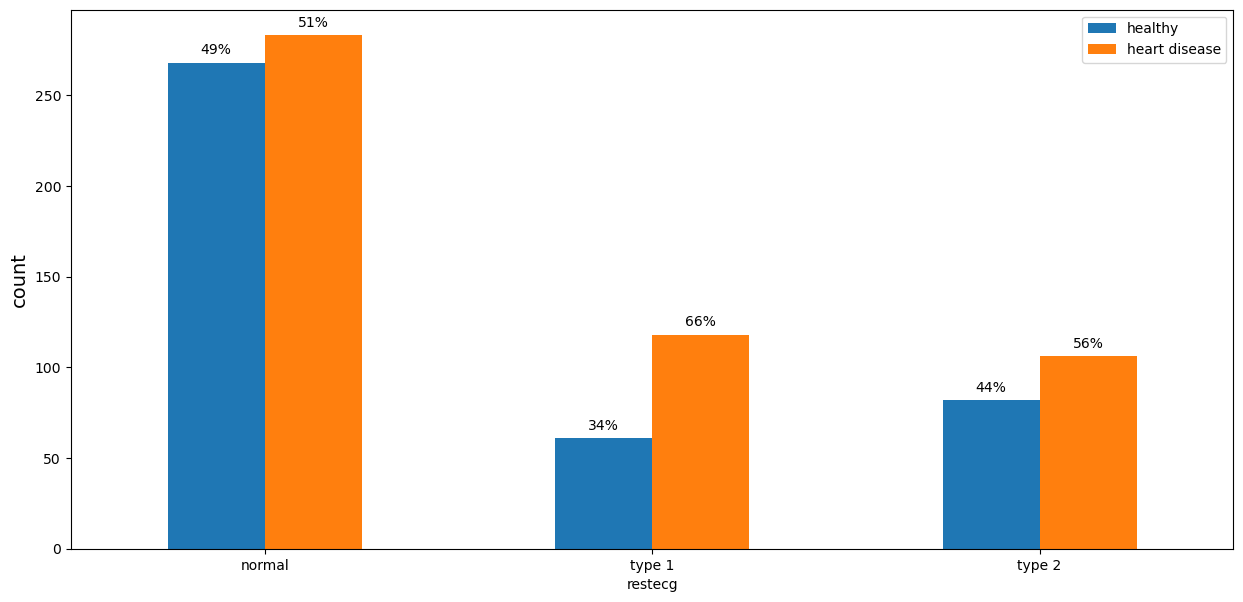

In [28]:
labels=['normal', 'type 1', 'type 2']
plot_categorical(df_eda, 'restecg', labels)

#### Maximum heart rate achieved ('thalach')

<AxesSubplot: ylabel='Frequency'>

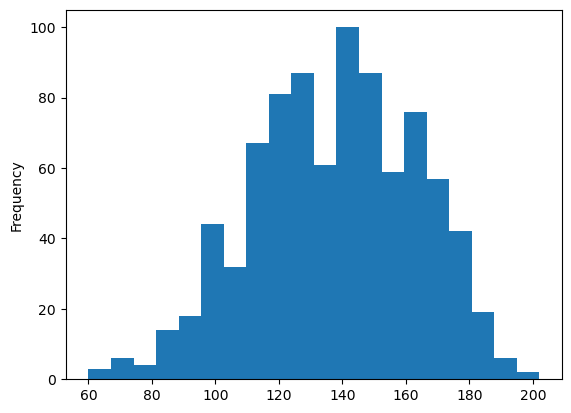

In [29]:
df_eda.thalach.plot.hist(bins=20)

Patients without heart disease are able to reach a higher maximum heart rate than patients with the disease.

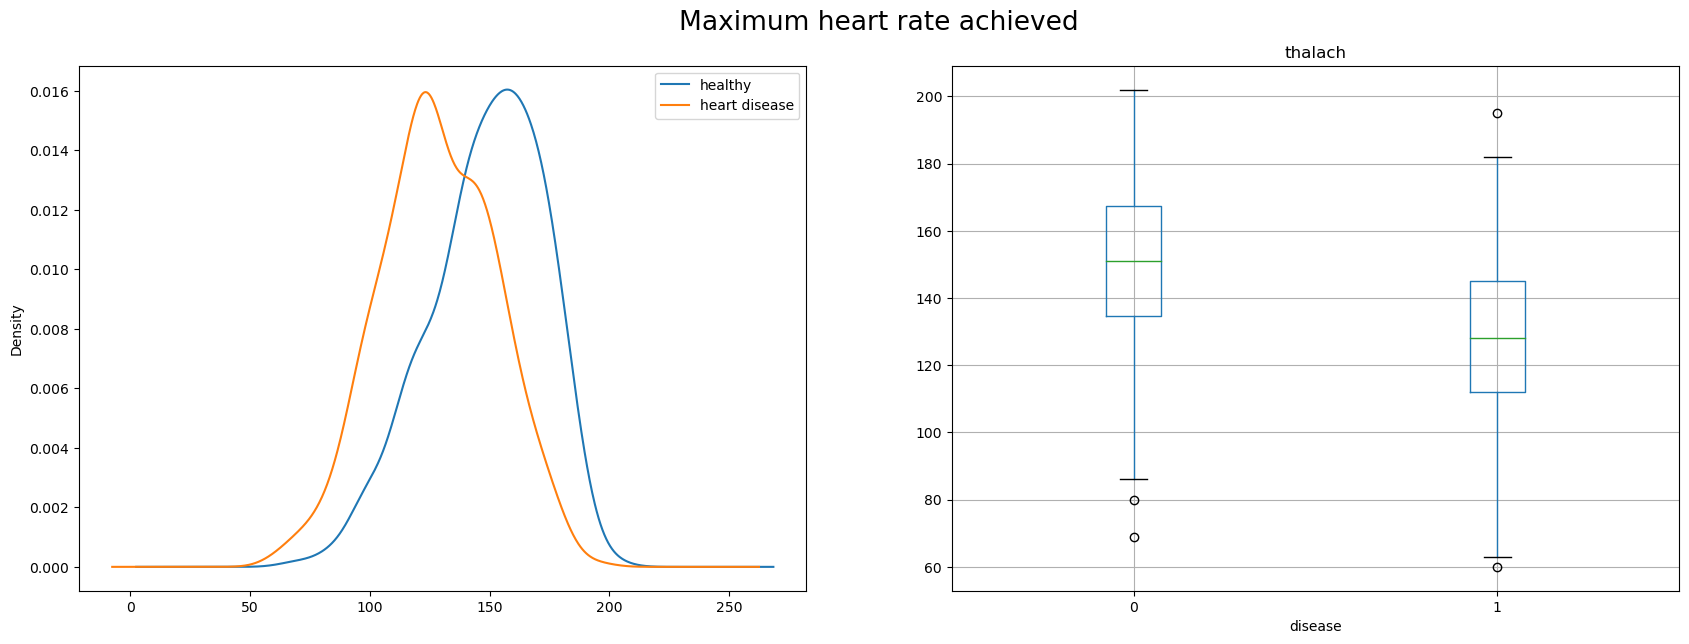

In [30]:
plot_numeric(df_eda, 'thalach', 'Maximum heart rate achieved')

#### ST depression (oldpeak)

<AxesSubplot: >

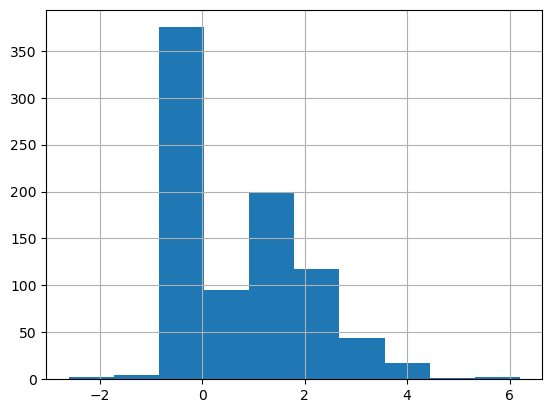

In [31]:
df_eda.oldpeak.hist()

There are some negative values. Replacing with nan.

<AxesSubplot: >

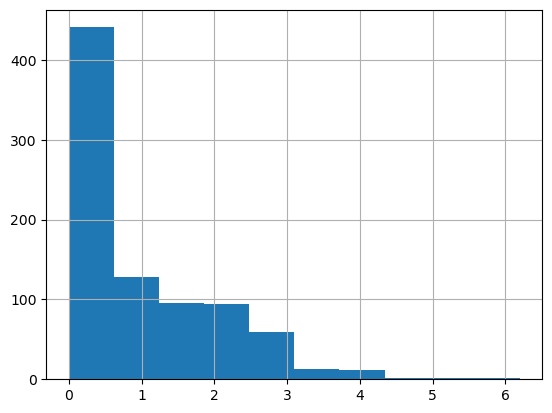

In [33]:
df_eda['oldpeak'] = df_eda['oldpeak'].apply(lambda x: np.nan if x < 0 else x)
df_eda.oldpeak.hist()

Oldpeak is another ECG parameter measuring ST depression during the exercise. It represents a distance on the ECG plot between specific points. There's a notable difference in distributions between the groups. Sick people on average have higher value of the parameter.

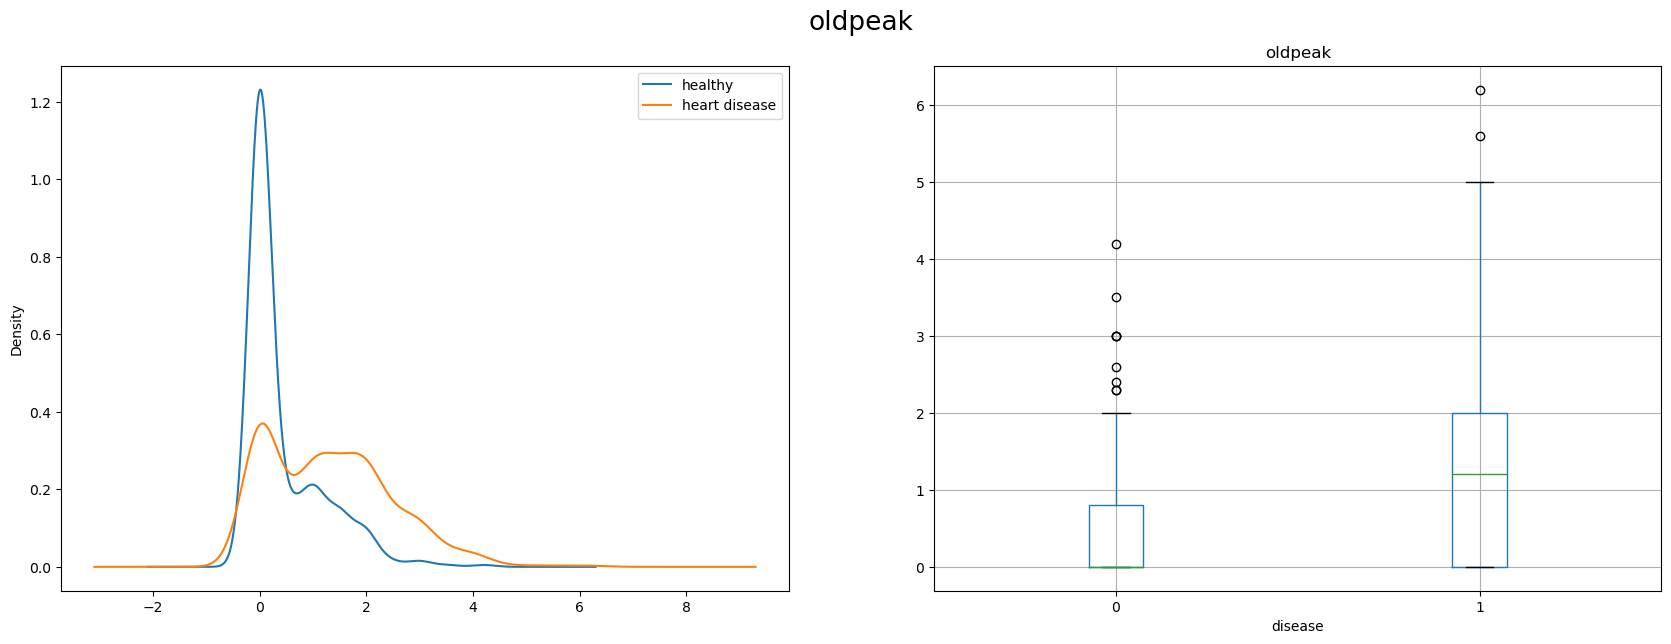

In [34]:
plot_numeric(df_eda, 'oldpeak', 'oldpeak')

In [35]:
describe_numeric(df_eda, 'oldpeak')

,oldpeak,healthy,sick
count,846.000000,387.000000,459.000000
mean,0.906265,0.425840,1.311329
std,1.071192,0.712184,1.153295
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.500000,0.000000,1.200000
75%,1.500000,0.800000,2.000000
max,6.200000,4.200000,6.200000


Patients with high olpeak values have higher chance of having herat disease.

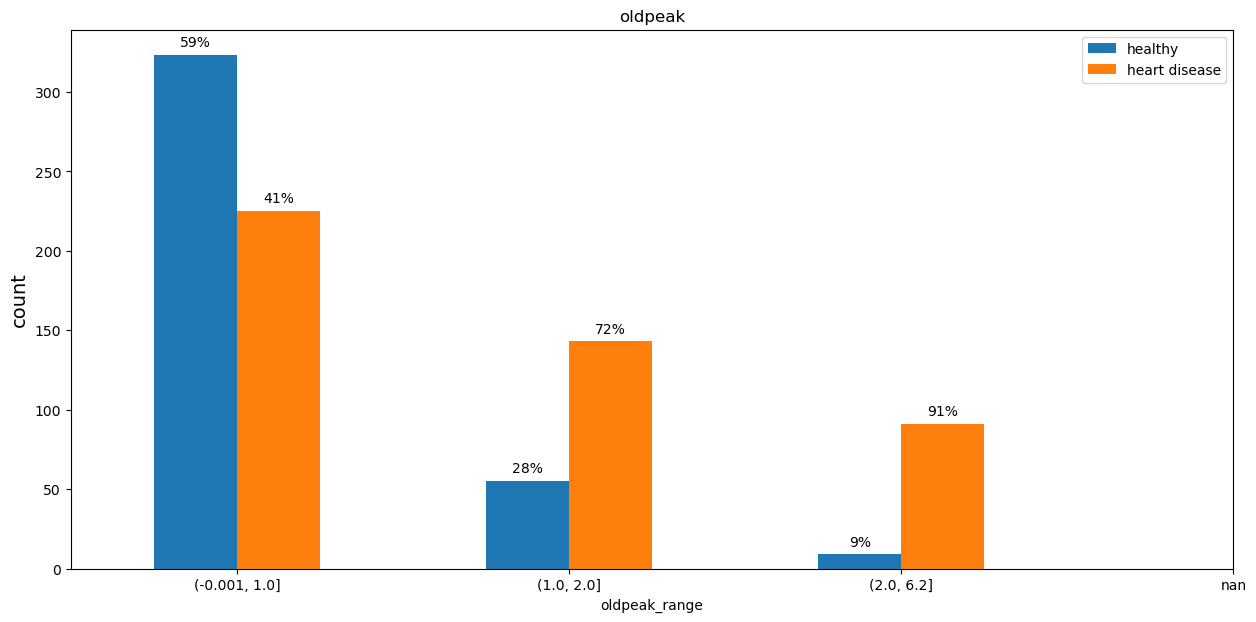

In [36]:
df_eda['oldpeak_range'] = pd.qcut(df_eda['oldpeak'], 5, duplicates = 'drop')
plot_categorical(df_eda, 'oldpeak_range', df_eda.oldpeak_range.unique().sort_values(), title = 'oldpeak')

#### The slope of the peak exercise ST segment ('slope')

This is another ECG parameter, measured during the exercise. Almost 80% of the patients with 'flat' or 'downslopping' slope parameter had heart disease. Most of the people with the 'upslopping' slope were healthy.

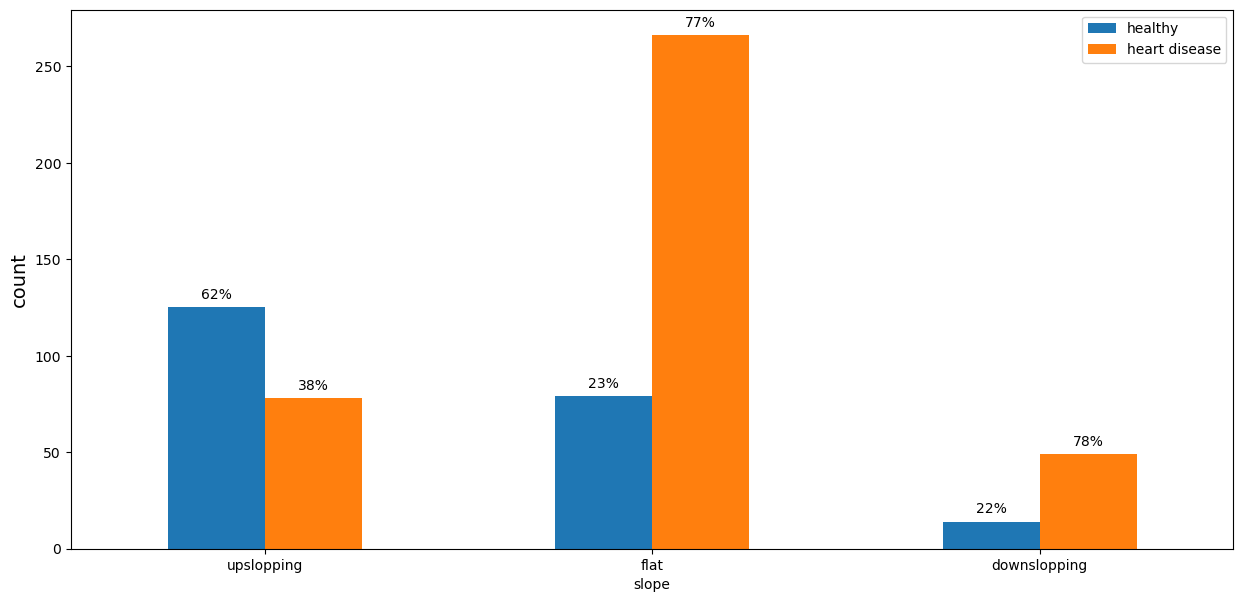

In [37]:
labels=["upslopping", "flat", "downslopping"]
plot_categorical(df_eda, 'slope', labels)

#### Thalassemia blood disorder ('thal')

People with this blood disorder are at risk of having heart disease with almost 80% for both type 1 and type 2 disorders.

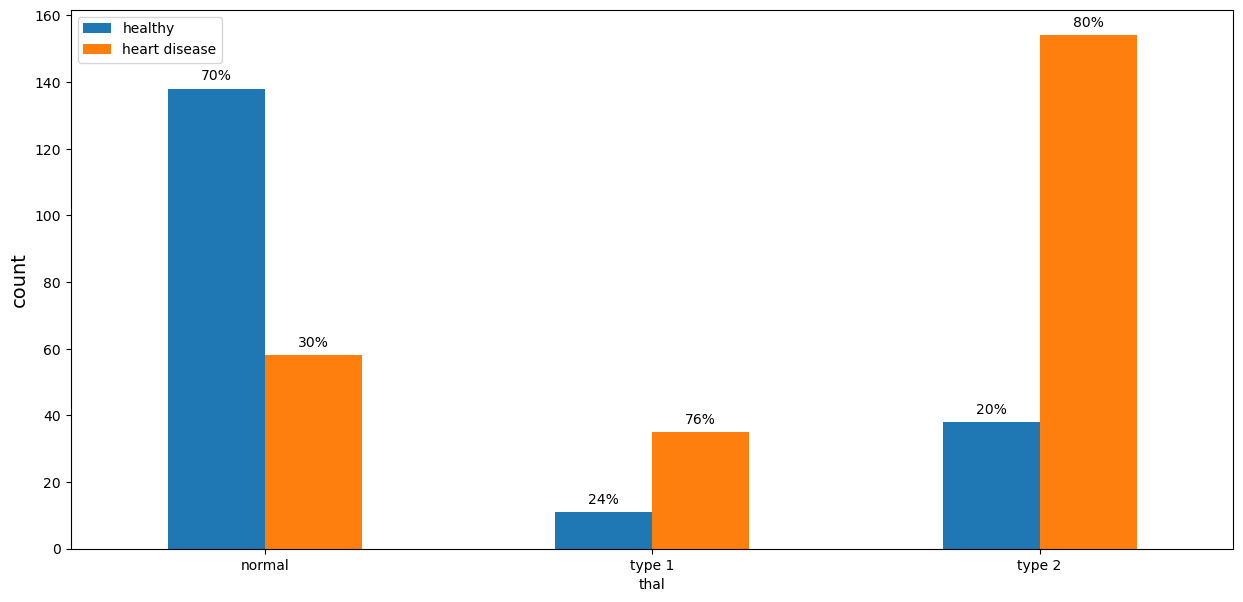

In [39]:
labels=['normal','type 1','type 2']
plot_categorical(df_eda, 'thal', labels)

### Numeric attributes relationships

Younger patients are able to achieve higher maximum heart rate. Patients with heart disease are older and have lower maximum heart rate.

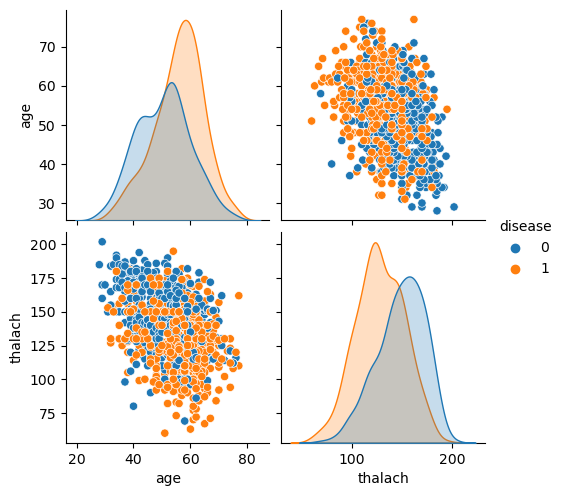

In [41]:
sns.pairplot(df_eda, hue='disease', vars=['age', 'thalach']);

Blood pressure is higher in older patients. But these factors do not form a clear separation between healthy and sick patients.

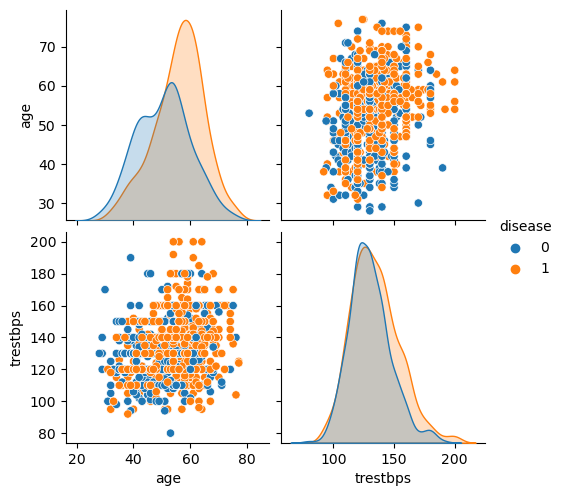

In [42]:
sns.pairplot(df_eda, hue='disease', vars=['age', 'trestbps']);

### EDA colclusion

Exploratory data analysis identified the following groups with a high risk of heart disease:

 - Patients with high cholesterol
 - Patients older than 54 years old
 - Male patients
 - Patients with high blood sugar
 - Patients with abnormalities in their ECG
 - Patient low maximum heart rate
 - Patients with high oldpeak value
 - Patients with slope that flat or downsloping
 - Patients with blocked heart vessels
 - Patients with thalassemia blood disorder
 - Patients with high blood pressure, more than 120 mmHg

## Data quality

### Incorrect values

There are some incorrect values in the dataset as it was discovered.

* Cholesterol ('chol') has lots of zeros.
* ST depression ('oldpeak') has some negative values. In the existing research this parameter is >= 0.
* Resting blood pressure ('trestbps') has one zero value.

### Missing values

Count incorrect values as missing values.

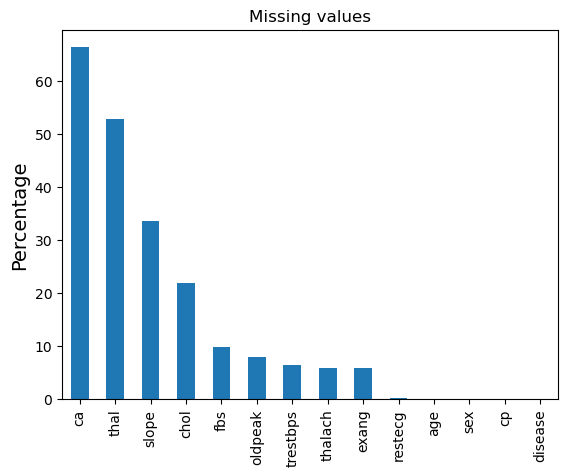

In [45]:
df_missing = df.copy()
df_missing.chol = df.chol.replace({0:np.nan})
df_missing.trestbps = df.trestbps.replace({0:np.nan})
df_missing.loc[df.oldpeak < 0, 'oldpeak'] = np.nan

plot_missing(df_missing)

# Data Preparation

## Data cleaning

Removing incorrect values.

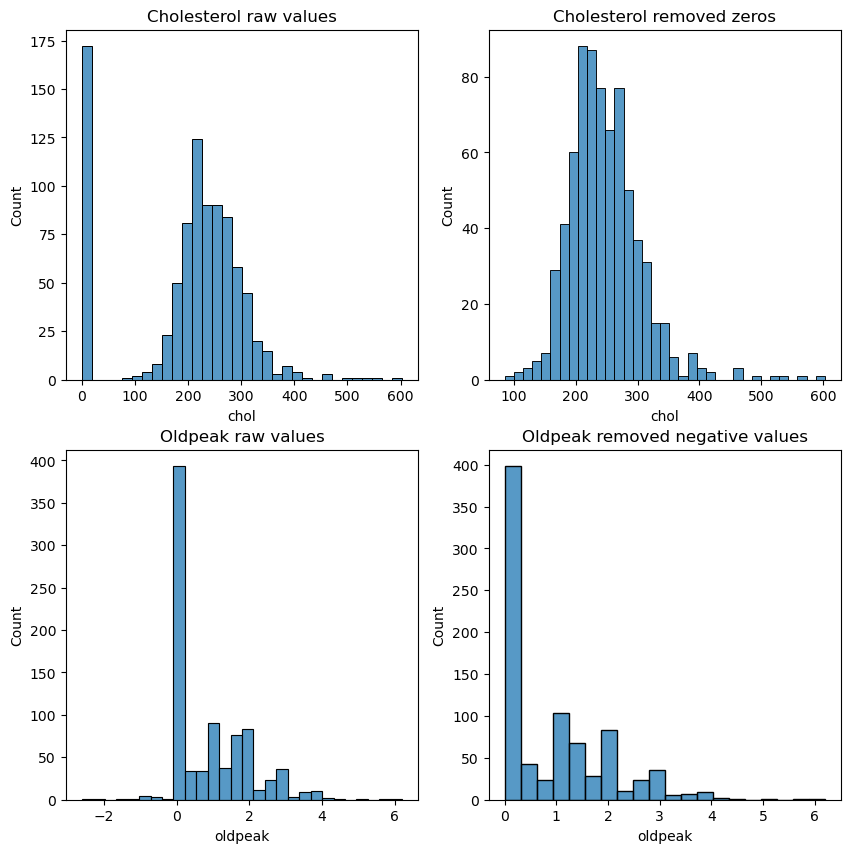

In [3]:
def remove_incorrect(data=pd.DataFrame):
  copy=df.copy()
  copy.chol.replace(0,np.nan,inplace=True)
  copy.trestbps.replace(0,np.nan,inplace=True)
  copy.loc[copy['oldpeak'] < 0, "oldpeak"] = np.nan
  return copy

df_clean = remove_incorrect(df)

#plot the result
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

#chol
sns.histplot(data=df, x="chol", ax = axs[0,0])
axs[0, 0].title.set_text('Cholesterol raw values')
sns.histplot(data=df_clean, x="chol", ax = axs[0,1])
axs[0, 1].title.set_text('Cholesterol removed zeros')

#oldpeak
sns.histplot(data=df, x="oldpeak", ax = axs[1,0])
axs[1, 0].title.set_text('Oldpeak raw values')
sns.histplot(data=df_clean, x="oldpeak", ax = axs[1,1])
axs[1, 1].title.set_text('Oldpeak removed negative values')

Deleting columns with more than 30% missing data

In [4]:
df_reduced = df_clean.drop(['ca', 'thal', 'slope'],axis=1)
df_reduced.head(1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,disease
0,32.0,1.0,1.0,95.0,NaN,NaN,0.0,127.0,0.0,0.7,1


Removing duplicate rows.

In [5]:
duplicates = df_reduced.loc[df_reduced.duplicated(), :] 
df_no_duplicates = df_reduced.drop_duplicates(keep='first') 
duplicates

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,disease
613,58.0,1.0,3.0,150.0,219.0,0.0,1.0,118.0,1.0,0.0,1
728,49.0,0.0,2.0,110.0,NaN,0.0,0.0,160.0,0.0,0.0,0


### Outliers

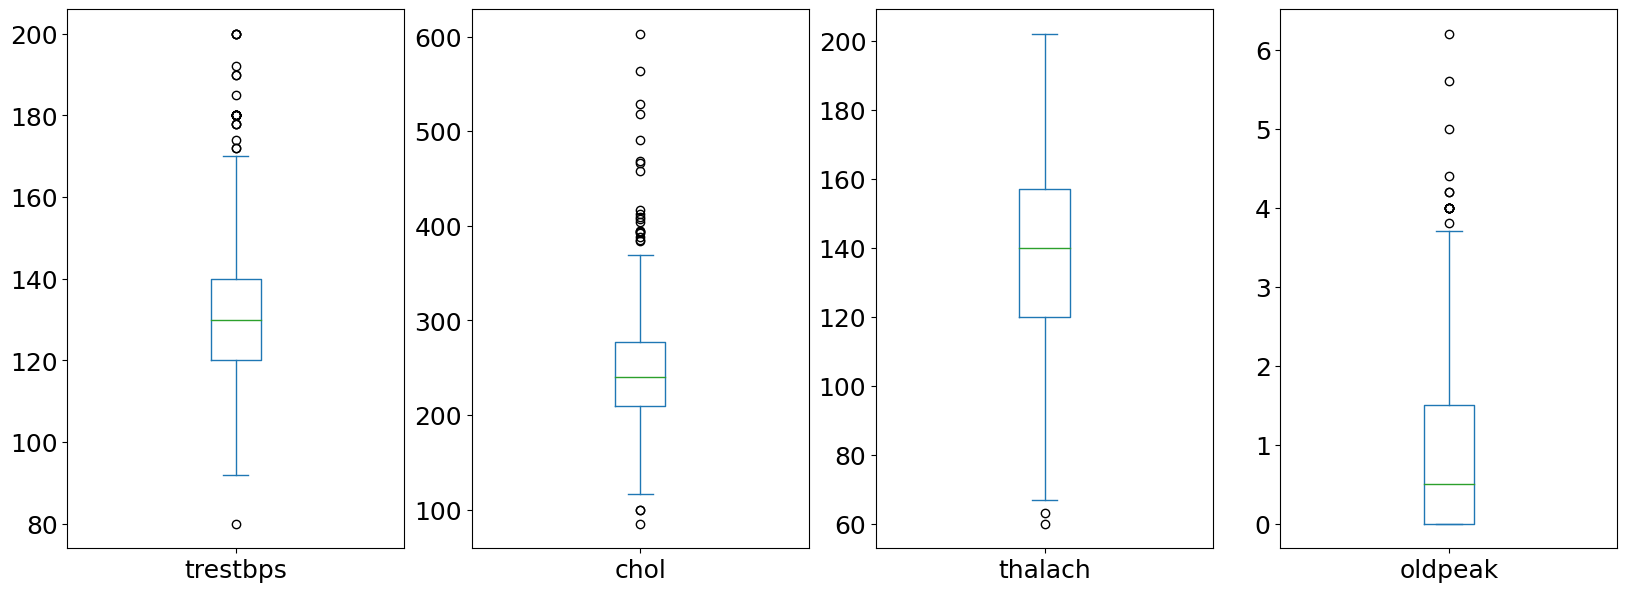

In [6]:
def find_outliers(data=pd.DataFrame):
    return [col for col in data.columns if has_outliers(data[col])]

def get_box_limits(col=pd.Series):
    q1 = col.quantile(.25)
    q3 = col.quantile(.75)
    IQR = q3 - q1
    ll = q1 - (1.5*IQR)
    ul = q3 + (1.5*IQR)
    return (ll, ul)

def has_outliers(col=pd.Series):
    ll, ul = get_box_limits(col)
    upper_outliers = col[col > ul].count() > 0
    lower_outliers = col[col < ll].count() > 0
    return upper_outliers or lower_outliers

outliers_columns = find_outliers(df_no_duplicates[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])

fig, axs = plt.subplots(1, len(outliers_columns), figsize = (20, 7))
for (i, col) in enumerate(outliers_columns):
   df_no_duplicates[col].plot.box(ax = axs[i], fontsize = 18)

These values are real, and removing them might affect the modeling, so I keep them.

## Statistical significance testing

The best resouce about univariate ans bivariate statistical analysis basics:

 - [univariate](https://www.youtube.com/playlist?list=PLqzoL9-eJTNDVNYtKrBKuFnshUoBGY593)
 - [bivariate](https://www.youtube.com/playlist?list=PLqzoL9-eJTNBq-C2sh46hYIlZYJ0Z1cIB)

### Chi square test for categorical data

In [7]:
from pandas.core.strings.accessor import isna
from itertools import combinations
from scipy.stats import chi2_contingency

def test(col1=pd.Series, col2=pd.Series, alpha=float):
  data_cont=pd.crosstab(col1, col2)
  p_value = chi2_contingency(data_cont)[1]
  return p_value > alpha

def color_df(x):
  if x == True:
    return 'color: %s' % 'red'
  elif isna(x): return None
  else: return 'color: %s' % 'green'

def show_chi_square_results(data=pd.DataFrame):
  categorical = ['sex','cp','fbs','restecg','exang', 'disease']
  cmb = list(combinations(categorical, 2))

  chi_square_results_df = pd.DataFrame(index = categorical, columns = categorical)
  for c in cmb:
    res = test(data[c[0]], data[c[1]], 0.05)
    chi_square_results_df.loc[c[0], c[1]] = res
    chi_square_results_df.loc[c[1], c[0]] = res

  return chi_square_results_df.style.applymap(color_df)

show_chi_square_results(df_no_duplicates)

,sex,cp,fbs,restecg,exang,disease
sex,nan,False,False,True,False,False
cp,False,nan,True,False,False,False
fbs,False,True,nan,False,True,False
restecg,True,False,False,nan,False,False
exang,False,False,True,False,nan,False
disease,False,False,False,False,False,nan


The table demonstrates if a variable is statistically independent from another variable(label 'True'). There are no independent variables for the target (disease) column.

### T-test for numeric features

Two-tailed two sample t-testing is performed.

**Null Hypothesis:** The means of features for patients with heart disease and healthy patients are the same.

**Alternative hypothesis:** There are statistically significant differences in the feature means for the healthy and sick patients.

In [8]:
from scipy.stats import ttest_ind

def test_numeric(data = pd.DataFrame, col=str):
    data = data[~data[col].isna()]
    _, p = ttest_ind(data[col], data['disease'], equal_var=False)
    return p

def show_ttest_results(data=pd.DataFrame):
  results = [(col, test_numeric(data, col))  for col in ['chol', 'trestbps', 'age', 'oldpeak', 'thalach']]
  return pd.DataFrame(results, columns = ['Column', 'p-value'])

In [9]:
show_ttest_results(df_no_duplicates)

,Column,p-value
0,chol,0.000000e+00
1,trestbps,0.000000e+00
2,age,0.000000e+00
3,oldpeak,9.389716e-19
4,thalach,0.000000e+00


I reject null hypothesis and state that there are statistically significant differences in the feature means for the healthy and sick patients. Keeping all the features.

## Split train/test

70% train, 30% test

In [10]:
train_data = df_no_duplicates.sample(frac=0.7, random_state=123)
test_data = df_no_duplicates[~df_no_duplicates.index.isin(train_data.index)]

### Data imputation

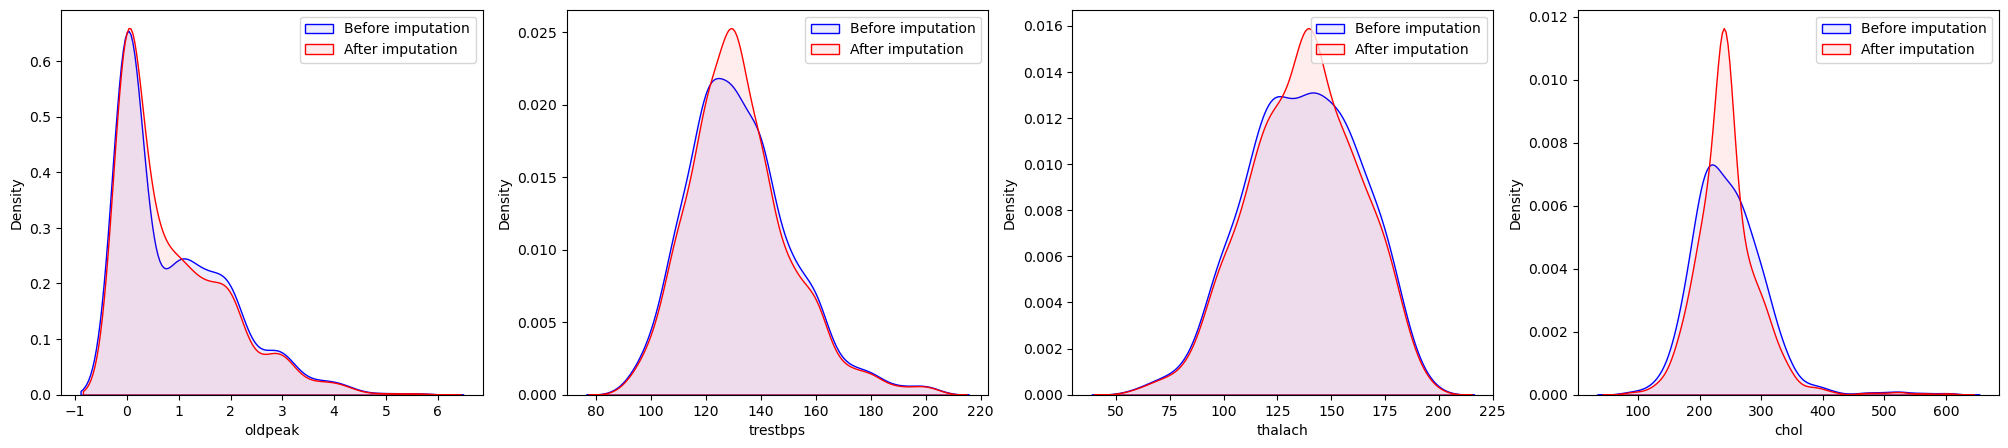

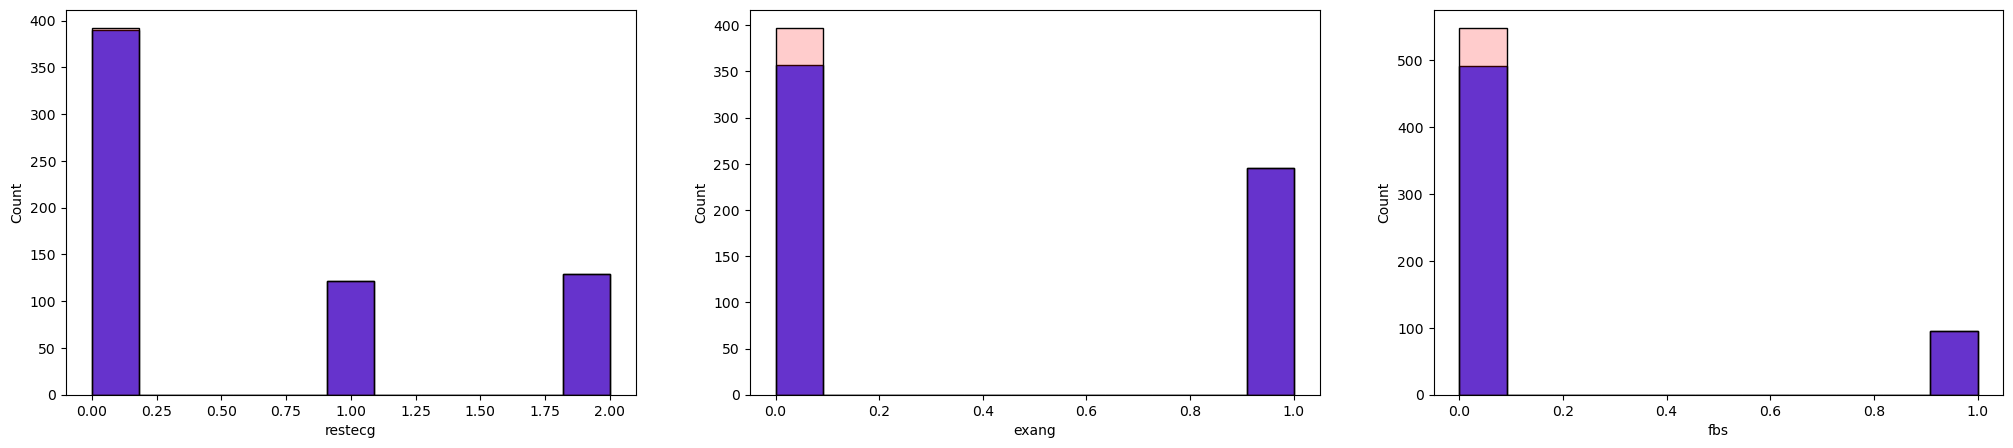

In [11]:
from scipy.stats import mode
from functools import partial

def impute(data,cols,impute_fn):
    imputed = data.copy()
    for col in cols:
        imputed[col + "_missing"] = imputed[col].isna().astype(int) # flag variable for missing 
        imputed[col] = impute_fn(imputed[col])#.fillna(imputed[col].mode()[0]) 
    return imputed

def impute_categorical(data=pd.DataFrame) -> pd.DataFrame:
    cols = ['restecg', 'exang', 'fbs']
    impute_fn = lambda x: x.fillna(x.mode()[0])
    return impute(data,cols,impute_fn)
    

def impute_numeric(data=pd.DataFrame, cols=list) -> pd.DataFrame:
    cols = ['oldpeak', 'trestbps', 'thalach', 'chol']
    impute_fn = lambda x: x.fillna(x.median())
    return impute(data,cols,impute_fn)

def plot_numeric_imputation(data_before=pd.DataFrame, data_after=pd.DataFrame):
  cols = ['oldpeak', 'trestbps', 'thalach', 'chol']
  fig, axs = plt.subplots(1, len(cols), figsize = (25, 5))
  for i, col in enumerate(cols):
    sns.kdeplot(data_before[col], color='b', fill=True, ax = axs[i], alpha = 0.07)
    sns.kdeplot(data_after[col], color='r', fill=True, ax = axs[i], alpha = 0.07)
    axs[i].legend(['Before imputation', 'After imputation'])

def plot_categorical_imputation(data_before=pd.DataFrame, data_after=pd.DataFrame):
  cols = ['restecg', 'exang', 'fbs']
  fig, axs = plt.subplots(1, len(cols), figsize = (25, 5))
  for i, col in enumerate(cols):
    sns.histplot(data=data_before, x=col, ax=axs[i], color='b')
    sns.histplot(data=data_after, x=col, ax=axs[i], color='r', alpha=0.2)
    
plot_numeric_imputation(train_data, impute_numeric(train_data))
plot_categorical_imputation(train_data, impute_categorical(train_data))

## One hot encoding

In [13]:
def encode_dummy(data = pd.DataFrame, drop_first=True) -> pd.DataFrame:
  df = data.copy()
  for col in ['cp', 'restecg']:
    dummy = pd.get_dummies(df[col], prefix = col,drop_first=drop_first)
    df = pd.concat([df, dummy], axis=1)
    df.drop(col, axis=1, inplace=True)
  return df

encode_dummy(train_data).head(5)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,disease,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0
349,47.0,1.0,112.0,204.0,0.0,143.0,0.0,0.1,0,0,0,1,0,0
654,38.0,1.0,140.0,297.0,0.0,150.0,0.0,0.0,0,1,0,0,0,0
7,38.0,1.0,115.0,NaN,0.0,128.0,1.0,0.0,1,0,1,0,0,0
571,54.0,1.0,NaN,182.0,0.0,NaN,NaN,NaN,0,1,0,0,1,0
171,65.0,0.0,140.0,417.0,1.0,157.0,0.0,0.8,0,0,1,0,0,1


## Feature Scaling

Normalization/Standardization

Machine learning algorithms like linear regression, logistic regression, neural network, etc. that use gradient descent as an optimization technique require data to be scaled.         
Distance algorithms like KNN, K-means, and SVM are most affected by the range of features Normalization/Standardization.Therefore, I scale the data before employing a distance based algorithm so that all the features contribute equally to the result.



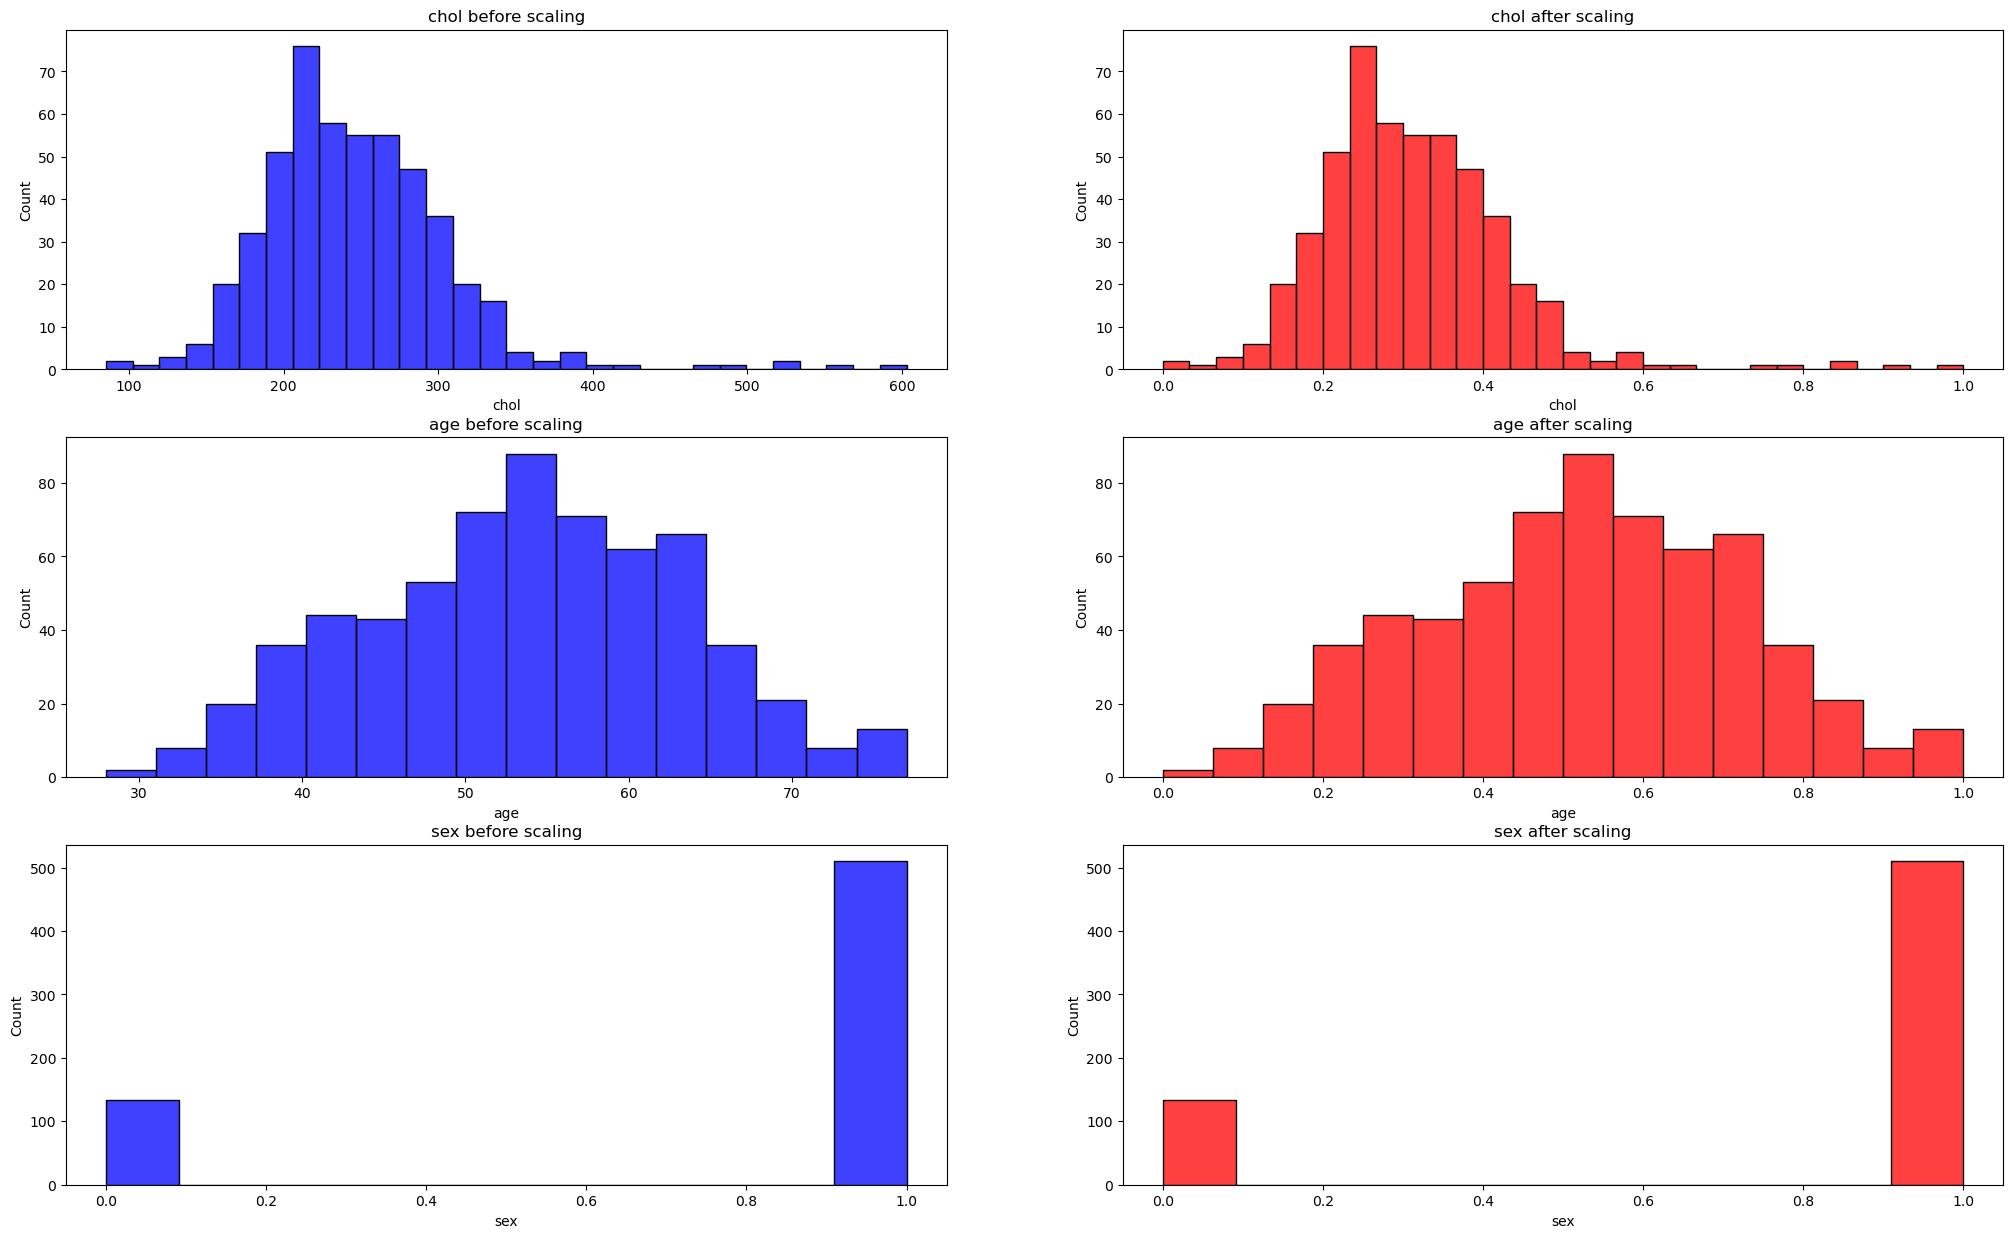

In [14]:
from sklearn.preprocessing import MinMaxScaler

def scale(data=pd.DataFrame):
  return pd.DataFrame(MinMaxScaler().fit_transform(data), columns=data.columns)

def plot_normalization(data_before=pd.DataFrame, data_after=pd.DataFrame, cols=str):
  fig, axs = plt.subplots(len(cols), 2, figsize = (25, 15))
  for i, col in enumerate(cols):
    sns.histplot(data_before[col], color='b', ax = axs[i, 0])
    axs[i, 0].title.set_text(col + ' before scaling')
    sns.histplot(data_after[col], color='r', ax = axs[i, 1])
    axs[i, 1].title.set_text(col + ' after scaling')

plot_normalization(train_data, scale(train_data), ['chol', 'age', 'sex'])


# Modeling

In [32]:
#| code-summary: "Helper functions"

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def run_modeling(model,train_data,test_data):
    x_train = train_data.drop('disease', axis=1)
    y_train = train_data['disease']
    model.fit(x_train, y_train)
      
    x_test = test_data.drop('disease', axis=1)
    y_test = test_data['disease']
    y_model = model.predict(x_test)
    return accuracy_score(y_test, y_model), model


def impute_all(data):
    return impute_categorical(impute_numeric(data))

def full_pipeline(data):
    data = impute_all(data)
    data = encode_dummy(data)
    return scale(data)


## Random forest

In [48]:
#| code-fold: false
rf_train_data  = impute_all(train_data)
rf_test_data  = impute_all(test_data)

acc, rf_model = run_modeling(RandomForestClassifier(random_state=0), rf_train_data,rf_test_data)
print(f'accuracy: {acc}')

accuracy: 0.7527272727272727


## Logistic regression

In [49]:
#| code-fold: false

lr_train_data = full_pipeline(train_data)
lr_test_data = full_pipeline(test_data)
    

acc, model = run_modeling(LogisticRegression(), lr_train_data, lr_test_data)
print(f'accuracy: {acc}')

accuracy: 0.7781818181818182


## SVM

There are many model parameters and they are not easy to choose, so I use the GridSearchCV tool in sklearn to help to complete the parameter selection. The main parameters include kernel, C and gamma

In [50]:
#| code-fold: false

from sklearn import svm
from sklearn.model_selection import GridSearchCV

parameters = {'kernel':('linear', 'rbf'), 'C':[1], 'gamma':[0.05, 0.07, 0.125, 0.25, 0.5]}
model = GridSearchCV(svm.SVC(), parameters, scoring='accuracy')

svm_train_data = full_pipeline(train_data)
svm_test_data = full_pipeline(test_data)

acc, model = run_modeling(model, svm_train_data, svm_test_data)
print(f'accuracy: {acc}')

accuracy: 0.7781818181818182


## Interpretation

I use information from the random forest feature importance to do interpretation.

From the random forest feature importance information I conclude that the most important variables for predicting heart disease are:

- Chest pain type (cp)
- Maximum heart rate achieved (thalach)
- Oldpeak
- Age
- Cholesterol

Meanwhile such parameters as blood sugar and the results of the electrocardiogram contributed the least to the heard disease prediction in the random forest model.

The most of the missing values flags were not important for the model.

<AxesSubplot: >

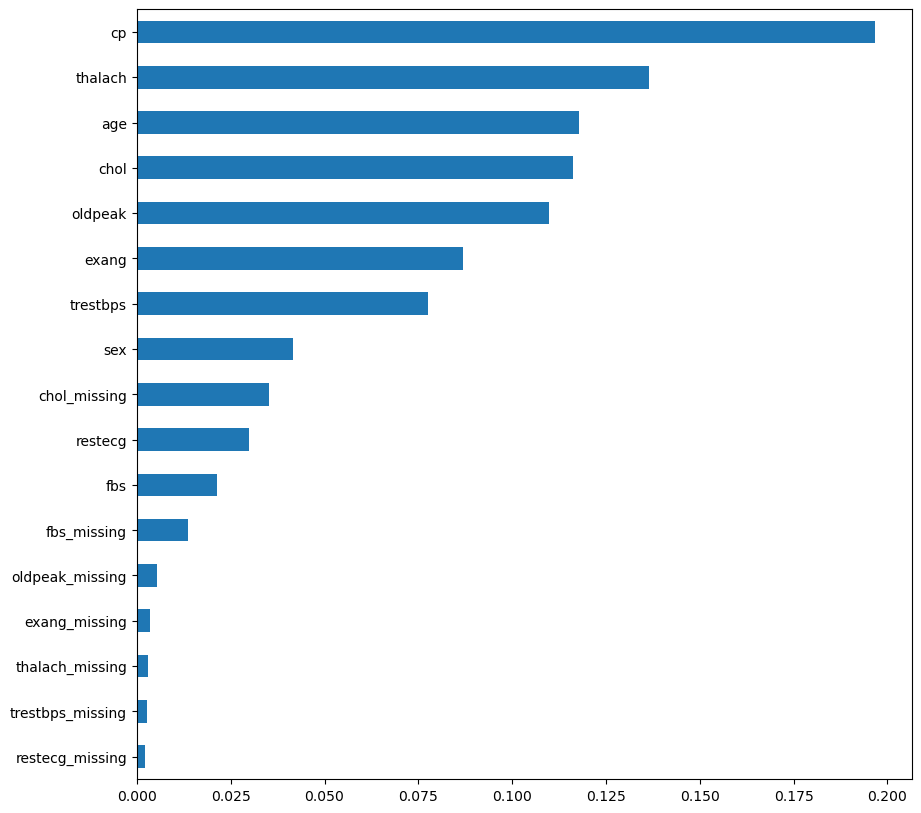

In [46]:
(pd.Series(rf_model.feature_importances_, index=rf_train_data.drop(['disease'], axis=1).columns).sort_values().plot(kind='barh', figsize=(10,10)))